# Offline vs cloud LLM tutoring — latency, cost and teaching quality

Everything below is **recomputed from the raw transcripts**, not from
copied figures. Change a board, re-run the notebook, and every table and chart
follows.

## What the data is

Five arms over one subject board (geography, 34 scenarios), all on the same
tutor build and the same simulated students:

| tier | arms |
|---|---|
| on-device (RTX 3090, 24 GB) | `qwen3-4B`, `qwen3.8-27B` |
| cloud API | `claude-opus-4-7`, `gemini-3.5-flash`, `gpt-5.4-mini` |

Raw inputs, all in this repository:

- `multi_turn_results/<board>/trace/<arm>.jsonl` — one JSON object per tutor
  RESPONSE: token buckets, tools called, the reply itself
- `multi_turn_results/<board>/<arm>.json` — per-scenario pass/fail
- `manual_grades/manual_grades_3runs_169.json` — 169 human verdicts across 8
  pedagogical dimensions
- `sweep_rtx3090_turnmode.log` — GPU concurrency sweep

**Geography only.** The maths boards are excluded because two of their lessons
hold fewer bank questions than a session consumes, so sessions end on the turn
cap rather than on the tutor's behaviour — a content defect that would read as
a model difference.

## A caution before the numbers

`passed` in the board files counts **deterministic assertions only** — the
session completed, tools fired, grading resolved. It is not a measure of
teaching. Every arm ran with `EVAL_SKIP_RUBRIC=1`, so the quality signal comes
from the human grades in §4 and nowhere else.

In [1]:
import json, pathlib, statistics, collections, sys
import matplotlib.pyplot as plt
# No Agg backend here: this notebook is meant to be READ, so charts must render
# in the page for anyone opening it on GitHub or nbviewer without running it.
# Each figure is also written to figures/ for the paper.
import pandas as pd

ROOT = pathlib.Path.cwd()
if ROOT.name == "offline_eval":
    ROOT = ROOT.parent
RES = ROOT / "offline_eval" / "multi_turn_results"
sys.path.insert(0, str(ROOT))

LOCAL, CLOUD, GREY = "#1b6ca8", "#c0562f", "#777777"
IS_LOCAL = lambda arm: arm.startswith("qwen")

# GEOGRAPHY ONLY. The maths boards are excluded: two of their lessons hold
# fewer bank questions than a session consumes, so sessions there end on the
# turn cap rather than on the tutor's behaviour. Every arm is depressed by the
# same content gap, so including them would price a content defect as a model
# difference.
BOARDS = {"geography": ["geo_4b_v2", "geo_27b_v2", "geo_cloud"]}
print("repo root:", ROOT)
print("boards found:", {k: [b for b in v if (RES/b).exists()] for k, v in BOARDS.items()})

repo root: /Users/edwardamoah/Documents/GitHub/ai-tutor
boards found: {'geography': ['geo_4b_v2', 'geo_27b_v2', 'geo_cloud']}


## 1. Load the raw data

Two sources, because they record different things:

- **`trace/<arm>.jsonl`** — one object per tutor RESPONSE from the engine:
  token buckets, tools called, retries, the reply. This is where cost comes
  from.
- **`<arm>.json`** — the board, whose `transcript` array carries `latency_ms`
  per message. This is where latency comes from, and it is timed around the
  whole tutor response as the simulated student experienced it: both model
  calls plus the platform's grading and database work between them.

A **tutor response** is one message from the tutor. The transcript alternates
tutor and student messages, so a session of 7 tutor responses contains 7 tutor
messages and 6-7 student replies. Student messages are excluded from the
latency figures: the student side is the simulator, not the system under
test.

Reading latency off the trace would silently yield nothing — the field is not
there — so the two are loaded separately rather than assumed to be one table.

In [2]:
def load_turns():
    rows = []
    for subject, boards in BOARDS.items():
        for board in boards:
            for f in sorted((RES / board / "trace").glob("*.jsonl")):
                for line in open(f):
                    try: r = json.loads(line)
                    except Exception: continue
                    rows.append({
                        "subject": subject, "board": board, "arm": f.stem,
                        "session": r.get("session_id"),
                        "tok_in": r.get("tok_in", 0) or 0,
                        "tok_cached": r.get("tok_cached", 0) or 0,
                        "tok_write": r.get("tok_write", 0) or 0,
                        "placeholder": bool(r.get("placeholder")),
                        "retries": r.get("retries", 0) or 0,
                        "verdict": r.get("verdict"),
                        "reply": r.get("reply") or "",
                    })
    return pd.DataFrame(rows)

def load_latency():
    # Tutor-message latencies, read from the board transcripts.
    rows = []
    for subject, boards in BOARDS.items():
        for board in boards:
            for f in sorted((RES / board).glob("*.json")):
                if f.name.startswith("partial_"):     # resume checkpoints
                    continue
                d = json.load(open(f))
                for res in d.get("results", []):
                    for t in res.get("transcript", []):
                        if t.get("latency_ms") is None:
                            continue
                        rows.append({"subject": subject, "board": board,
                                     "arm": f.stem, "role": t.get("role"),
                                     "sec": t["latency_ms"] / 1000,
                                     "scenario": res.get("scenario_id")})
    return pd.DataFrame(rows)

turns = load_turns()
msgs = load_latency()
print(f"{len(turns):,} traced tutor responses across {turns.arm.nunique()} arms")
print(f"{len(msgs):,} timed messages "
      f"({(msgs.role=='tutor').sum():,} tutor, {(msgs.role=='student').sum():,} student)")
turns.groupby(["subject", "arm"]).agg(
    responses=("session", "size"), sessions=("session", "nunique"),
    placeholders=("placeholder", "sum"), retries=("retries", "sum"))

1,526 traced tutor responses across 5 arms
2,882 timed messages (1,526 tutor, 1,356 student)


responses  sessions  placeholders  retries
subject   arm                                                             
geography claude-opus-4-7             314        34             0        0
          gemini-3.5-flash            310        34             0        0
          gpt-5.4-mini                295        34             0        0
          qwen3-4b-jetson             313        34             0        9
          qwen3.8-27b-instruct        294        34             0        0

**Zero placeholders and zero retries everywhere** is the first thing to check.
A placeholder means a response fell back to canned text after a failed call; any
non-zero count would mean the latency and quality numbers are measuring a
degraded system rather than the real one.

## 2. Latency

The number a student actually waits for one tutor reply.

In [3]:
# Tutor messages only: the student side is the simulator, not the system
# under test, and including it would dilute the number a real student waits.
TUTOR_ROLE = "tutor"      # transcript roles are tutor/student
lat = (msgs[msgs.role == TUTOR_ROLE]
            .groupby(["subject", "arm"])["sec"]
            .agg(responses="size", p50="median",
                 p95=lambda s: s.quantile(0.95), max="max")
            .round(2).reset_index())
lat_wide = lat.pivot(index="arm", columns="subject",
                     values=["p50", "p95"]).sort_values(("p50", "geography"))
lat_wide

,p50,p95
subject,geography,geography
arm,,
gpt-5.4-mini,1.65,3.13
claude-opus-4-7,4.27,6.34
qwen3-4b-jetson,5.09,8.55
gemini-3.5-flash,10.55,17.16
qwen3.8-27b-instruct,19.62,26.36


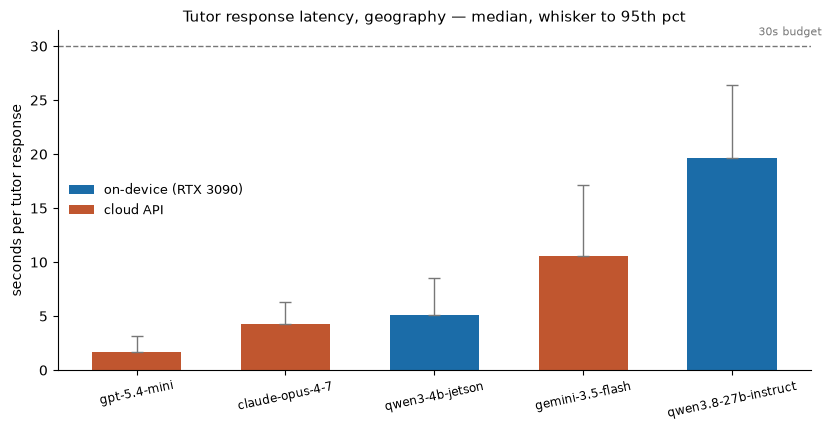

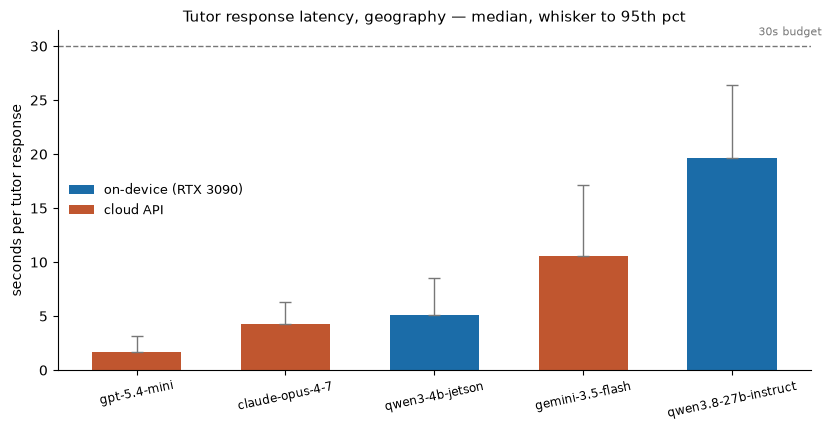

In [4]:
arms = list(lat_wide.index)
fig, ax = plt.subplots(figsize=(8.4, 4.4))
p50 = [lat_wide.loc[a, ("p50", "geography")] for a in arms]
p95 = [lat_wide.loc[a, ("p95", "geography")] for a in arms]
ax.bar(range(len(arms)), p50, 0.6,
       yerr=[[0]*len(p50), [b - a for a, b in zip(p50, p95)]],
       color=[LOCAL if IS_LOCAL(a) else CLOUD for a in arms],
       capsize=4, error_kw={"ecolor": GREY, "lw": 1})
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=LOCAL, label="on-device (RTX 3090)"),
                   Patch(facecolor=CLOUD, label="cloud API")],
          fontsize=9, frameon=False)
ax.set_xticks(range(len(arms))); ax.set_xticklabels(arms, fontsize=8.5, rotation=12)
ax.set_ylabel("seconds per tutor response")
ax.set_title("Tutor response latency, geography — median, whisker to 95th pct",
             fontsize=11)
ax.axhline(30, ls="--", lw=1, color=GREY)
ax.text(len(arms)-0.4, 31, "30s budget", fontsize=8, color=GREY, ha="right")
for s in ("top", "right"): ax.spines[s].set_visible(False)
fig.tight_layout(); fig.savefig("figures/fig1_latency.png", dpi=200)
fig

**The local 4B is not the slow option.** At 5.09s per response it beats Gemini
Flash (10.55s) and sits close to Opus (4.27s). The slowest cloud arm is slower
than the faster local one — the opposite of the usual assumption about
on-device inference.

## 3. Cost

### 3.1 Metered cloud spend, from the token buckets

The three buckets are **disjoint**: a provider's `input_tokens` excludes cached
tokens, so the prompt's true size is fresh + cached + written. Treating the
first as the total makes cache reads look larger than the input and prices a
run negative.

In [5]:
PRICES = {"claude-opus-4-7": 5.00, "gemini-3.5-flash": 0.30, "gpt-5.4-mini": 0.25}
OUT_PRICES = {"claude-opus-4-7": 25.00, "gemini-3.5-flash": 2.50, "gpt-5.4-mini": 2.00}
CACHE_READ, CACHE_WRITE = 0.10, 1.25       # multiples of the input rate
# Output tokens are not recorded by the tracer, so they are estimated from
# reply length at ~4 chars/token plus ~25 tokens for call 1's tool selection.
# They are only 6-8% of the bill, but omitting them understates every cloud
# arm — and made this notebook disagree with cost_audit.py by $1.19.
CHARS_PER_TOKEN, CALL1_OUT = 4.0, 25

cloud = turns[turns.arm.isin(PRICES)]
cloud = cloud.assign(out_tok=cloud.reply.str.len()/CHARS_PER_TOKEN + CALL1_OUT)
cost = (cloud.groupby(["subject", "arm"])
        .agg(fresh=("tok_in", "sum"), cached=("tok_cached", "sum"),
             written=("tok_write", "sum"), out_tok=("out_tok", "sum"),
             sessions=("session", "nunique"))
        .reset_index())
rate = cost.arm.map(PRICES)
out_rate = cost.arm.map(OUT_PRICES)
cost["hit_%"] = (100 * cost.cached / (cost.fresh + cost.cached + cost.written)).round(0)
cost["cost_exact"] = ((cost.fresh*rate + cost.cached*rate*CACHE_READ
                   + cost.written*rate*CACHE_WRITE
                   + cost.out_tok*out_rate) / 1e6)
cost["cost_usd"] = cost.cost_exact.round(2)
cost["uncached_exact"] = ((cost.fresh + cost.cached + cost.written) * rate
                          + cost.out_tok*out_rate) / 1e6
cost["uncached_usd"] = cost.uncached_exact.round(2)
cost["usd_per_session"] = (cost.cost_usd / cost.sessions).round(4)
display(cost)
# Totalled from unrounded values: summing the rounded per-arm column instead
# accumulates rounding error and disagrees with the exported dataset by a cent.
print(f"total metered spend  ${cost.cost_exact.sum():.2f}"
      f"   uncached would be ${cost.uncached_exact.sum():.2f}"
      f"   caching saved ${cost.uncached_exact.sum()-cost.cost_exact.sum():.2f}")

,subject,arm,fresh,cached,written,out_tok,sessions,hit_%,cost_exact,cost_usd,uncached_exact,uncached_usd,usd_per_session
0,geography,claude-opus-4-7,1504857,4124127,415837,41884.50,34,68.0,13.232442,13.23,31.271217,31.27,0.3891
1,geography,gemini-3.5-flash,5557243,244212,0,34996.50,34,4.0,1.761991,1.76,1.827928,1.83,0.0518
2,geography,gpt-5.4-mini,3613357,2209408,0,31253.75,34,38.0,1.021082,1.02,1.518199,1.52,0.0300


total metered spend  $16.02   uncached would be $34.62   caching saved $18.60


Note **Gemini's cache barely engages** (single-digit hit rate) against Opus's
~70%. On a workload that re-sends the same static prefix every response,
reads should dominate after the first one of a session. It costs little at Flash
prices, but the same behaviour on a heavier tier would re-bill the whole prefix
every response.

### 3.2 On-device: capital, not a per-token price

| item | cost |
|---|---:|
| NVIDIA RTX 3090, 24 GB | **$2,500**, one-off |

Both on-device models run on this one card, so the hardware cost is the same
whichever is deployed, and there is no per-token charge at all.

That is the whole difference. A metered service is paid for again with every
session; a bought card is paid for once. Going further — cost per student per
year, or a break-even against teacher time — needs assumptions about usage
intensity, card lifetime and wage levels that this study did not measure, and
those assumptions would drive the answer more than anything measured here.

## 4. Teaching quality — the central result

Graded in the viewer's Grade tab against the eight dimensions of
`ai_tutor/apps/benchmark/pedagogy.py`. A session passes only if **every
applicable dimension** sits at its desideratum — all-or-nothing, `n/a`
excluded rather than counted as failure. The pass rule here is the same Python
the dashboard uses, imported rather than reimplemented.

In [6]:
from ai_tutor.apps.benchmark import pedagogy as P

gfile = ROOT / "offline_eval" / "manual_grades" / "manual_grades_3runs_169.json"
G = json.load(open(gfile))
DIMS = G["dimensions"]
# Incomplete gradings are excluded entirely: an unanswered dimension is not a
# "no", and scoring it as one would invent failures.
complete = {k: v for k, v in G["verdicts"].items() if len(v.get("d", {})) == len(DIMS)}
print(f"{len(G['verdicts'])} verdicts stored, {len(complete)} complete, "
      f"{sum(1 for v in complete.values() if v.get('peeked'))} peeked")

complete_by_arm = collections.defaultdict(list)
for k, v in complete.items():
    complete_by_arm[k.split("|")[1]].append(v)

qual = collections.defaultdict(lambda: [0, 0])
for k, v in complete.items():
    arm = k.split("|")[1]
    qual[arm][0] += 1
    qual[arm][1] += bool(P.session_passes(v["d"]))
quality = pd.DataFrame([{"arm": a, "graded": n, "passed": p,
                         "pass_rate_%": round(100*p/n, 1)}
                        for a, (n, p) in qual.items()]).sort_values(
                        "pass_rate_%", ascending=False).reset_index(drop=True)
quality

170 verdicts stored, 169 complete, 0 peeked


,arm,graded,passed,pass_rate_%
0,claude-opus-4-7,34,34,100.0
1,qwen3.8-27b-instruct,34,33,97.1
2,gpt-5.4-mini,33,29,87.9
3,gemini-3.5-flash,34,24,70.6
4,qwen3-4b-jetson,34,23,67.6


In [7]:
DES = {d.key: d.desideratum for d in P.DIMENSIONS}
recs = []
for k, v in complete.items():
    arm = k.split("|")[1]
    for dim, val in v["d"].items():
        if val == "n/a":       # unscorable by the taxonomy, not a failure
            continue
        recs.append({"arm": arm, "dimension": dim, "fail": val != DES.get(dim)})
fails = (pd.DataFrame(recs).groupby(["dimension", "arm"])["fail"]
         .mean().mul(100).round(0).unstack(fill_value=0))
# All eight are shown, including the four every arm passes. A table that hides
# them reports only where models differ and loses the equally useful finding
# that no model failed to spot a mistake, locate it, stay encouraging, or
# sound human. Rows are ordered as pedagogy.py asks them, not by failure rate.
fails = fails.reindex([d.key for d in P.DIMENSIONS]).fillna(0)
fails["desideratum"] = [DES[k] for k in fails.index]
display(fails)

arm,claude-opus-4-7,gemini-3.5-flash,gpt-5.4-mini,qwen3-4b-jetson,qwen3.8-27b-instruct,desideratum
dimension,,,,,,
mistake_identification,0.0,0.0,0.0,0.0,0.0,yes
mistake_location,0.0,0.0,0.0,0.0,0.0,yes
revealing_answer,0.0,3.0,9.0,32.0,0.0,no
providing_guidance,0.0,24.0,3.0,0.0,0.0,yes
actionability,0.0,0.0,0.0,15.0,0.0,yes
coherence,0.0,6.0,0.0,0.0,3.0,yes
tutor_tone,0.0,0.0,0.0,0.0,0.0,encouraging
human_likeness,0.0,0.0,0.0,0.0,0.0,yes


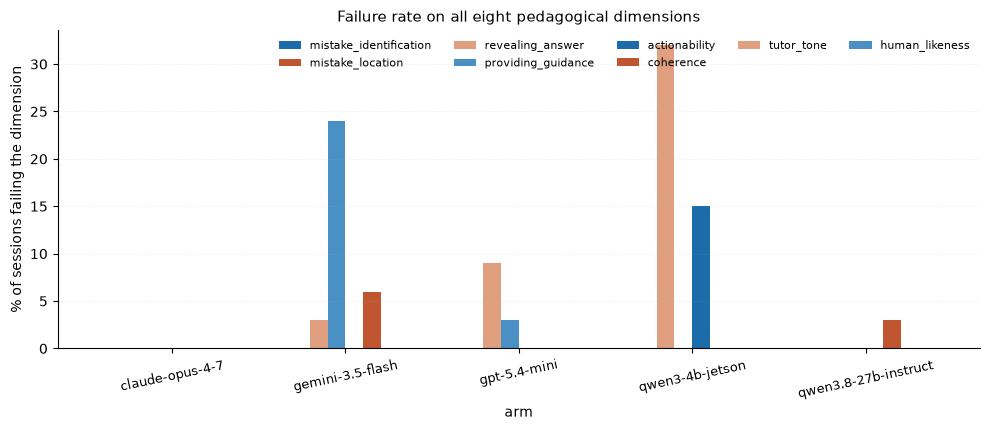

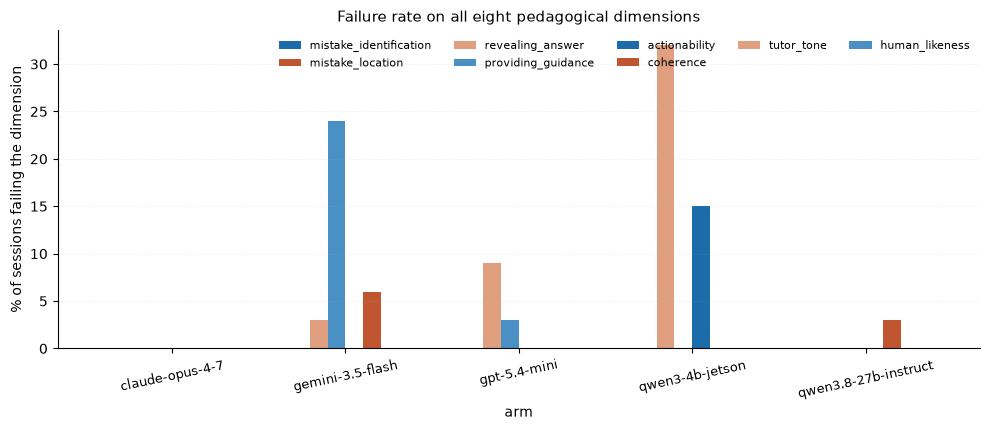

In [8]:
ax = fails.drop(columns="desideratum").T.plot(kind="bar", figsize=(10, 4.4), width=0.82,
                  color=["#1b6ca8", "#c0562f", "#e0a080", "#4a90c4"])
ax.set_ylabel("% of sessions failing the dimension")
ax.set_title("Failure rate on all eight pedagogical dimensions", fontsize=11)
ax.legend(fontsize=8, frameon=False, ncol=5, title=None)
ax.grid(axis="y", alpha=0.25, ls=":")
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.xticks(rotation=12, fontsize=9); plt.tight_layout()
plt.savefig("figures/fig4_dimensions.png", dpi=200); plt.gcf()

A single failure rate hides *how* a dimension failed. `to_some_extent` is a
tutor being vague; `no` is a tutor being wrong; `yes_correct` on
`revealing_answer` is a tutor handing over the answer. Different problems,
different fixes — so the verdicts are shown as recorded.

In [9]:
detail = []
for dim in [d.key for d in P.DIMENSIONS]:
    for arm, vs in complete_by_arm.items():
        c = collections.Counter(v["d"][dim] for v in vs)
        for val, n in c.items():
            if val not in ("n/a", DES[dim]):
                detail.append({"dimension": dim, "arm": arm,
                               "verdict recorded": val, "sessions": n})
pd.DataFrame(detail).sort_values(["dimension", "sessions"],
                                 ascending=[True, False]).reset_index(drop=True)

,dimension,arm,verdict recorded,sessions
0,actionability,qwen3-4b-jetson,to_some_extent,5
1,coherence,gemini-3.5-flash,to_some_extent,2
2,coherence,qwen3.8-27b-instruct,to_some_extent,1
3,providing_guidance,gemini-3.5-flash,to_some_extent,8
4,providing_guidance,gpt-5.4-mini,to_some_extent,1
5,revealing_answer,qwen3-4b-jetson,yes_correct,11
6,revealing_answer,gpt-5.4-mini,yes_correct,3
7,revealing_answer,gemini-3.5-flash,yes_correct,1


**Every arm scored 100% on four of the eight dimensions** — mistake
identification, mistake location, tutor tone and human-likeness. No model
struggled to spot an error, locate it, stay encouraging, or sound human.

All separation is in the other four, and each tier fails differently:

- **qwen3-4B** hands over the answer in 32% of sessions (11 of 34, every one of
  them the *correct* answer) and is vague about the next step in 15%. It knows
  the answer and tells the student — a failure of pedagogical restraint, not of
  capability.
- **Gemini 3.5 Flash** gives only partial guidance in 24% of sessions — the
  largest single weakness of any arm, and why a cloud model finishes below an
  on-device one.
- **qwen3.8-27B** fails once, on coherence, across 34 sessions.
- **Opus 4.7** does not fail on any dimension.

Because the gap is a few specific behaviours rather than general competence, it
is the kind of thing prompt and policy can address — the practically important
finding for anyone deploying the smaller model.

## 5. Concurrency — how many students one card serves

From `sweep_rtx3090_turnmode.log`. Each level fires N simultaneous **whole
tutor responses** (the short tool-picking call, then the full reply) and
reports how
latency degrades. Requests beyond the server's slot count queue rather than
fail, so N can exceed the slots.

In [10]:
import re
_HDR = re.compile(r"^#+ (\S+) slots=(\d+)")
_ROW = re.compile(r"^\s*(\d+)\s+\d+\s+([\d.]+)s\s+([\d.]+)s")
sweep, key = [], None
for line in open(ROOT / "offline_eval" / "sweep_rtx3090_turnmode.log"):
    h = _HDR.match(line)
    if h: key = (h.group(1), int(h.group(2))); continue
    r = _ROW.match(line)
    if r and key:
        sweep.append({"model": key[0], "slots": key[1], "N": int(r.group(1)),
                      "turn_p50": float(r.group(2)), "turn_p95": float(r.group(3))})
sweep = pd.DataFrame(sweep)
display(sweep)

BUDGET = 30.0    # seconds a student will wait for one tutor response
cap = (sweep[sweep.turn_p50 <= BUDGET].groupby("model")["N"].max()
       .rename(f"max concurrent @{BUDGET:.0f}s median").to_frame())
cap[f"@{BUDGET:.0f}s 95th pct"] = sweep[sweep.turn_p95 <= BUDGET].groupby("model")["N"].max()
cap

,model,slots,N,turn_p50,turn_p95
0,qwen3-4b-ctx8k,24,1,2.6,2.5
1,qwen3-4b-ctx8k,24,32,20.0,28.6
2,qwen3-4b-ctx8k,24,48,28.8,36.3
3,qwen3-4b-ctx8k,24,64,39.4,51.1
4,qwen3-4b-ctx8k,24,80,44.0,59.9
5,qwen3.8-27b-instruct,4,1,8.9,8.8
6,qwen3.8-27b-instruct,4,4,22.6,28.3
7,qwen3.8-27b-instruct,4,6,31.5,42.8
8,qwen3.8-27b-instruct,4,8,39.0,52.6
9,qwen3.8-27b-instruct,4,12,55.6,77.6


,max concurrent @30s median,@30s 95th pct
model,,
qwen3-4b-ctx8k,48,32
qwen3.8-27b-instruct,4,4


**This is the deployment decision.** The 27B teaches nearly as well as a
frontier model but serves a handful of students at once; the 4B serves an order
of magnitude more and reveals the answer far too often. Fixing the 4B's
revealing-answer behaviour is worth more than any model swap available here —
it is the only change that would give a full class frontier-adjacent tutoring
on one card.

## 6. Summary

| | |
|---|---|
| **Quality** | the on-device 27B reaches 97% against Opus's 100%, and beats both cheaper cloud models |
| **Failure modes** | all separation sits in 4 of 8 dimensions; every arm is perfect on the other 4 |
| **Latency** | the on-device 4B beats two of three cloud arms |
| **Cost** | cloud is metered per session and repeats; the card is $2,500 once |
| **Capacity** | the 27B serves ~4 concurrent students, the 4B ~48 |

### What this does not establish

- **One subject.** All of this is geography. Whether the ranking holds on a
  more reasoning-heavy subject is untested here.
- **Tutoring quality, not learning.** The grades record whether experts judged
  the tutoring sound. Whether students learn more would need a controlled
  trial, which this is not.
- **No total cost of ownership.** The cost section reports published token
  prices, what this run consumed, and the price of the card. It deliberately
  stops short of cost per student per year, which would need assumptions about
  usage, card lifetime and staff time that were not measured.
- **One grader.** 169 sessions, no second rater, so no inter-rater
  reliability figure.